# PCA-based exploration of biological and technical variation in Xenium data

In this notebook, we use PCA and linear modeling to investigate the main sources of variation in Xenium data generated with the 480-gene and 5k-gene panels, both segmented using Proseg. We:

- read and preprocess the data,
- initialize SegTraQ objects,
- perform label transfer from a reference scRNA-seq dataset,
- compute baseline SegTraQ metrics,
- compare transcript count distributions per gene and per cell across both datasets,
- and use PCA together with regression on transferred cell type labels to assess which components are driven by biological identity versus other sources of variation.

## Read SpatialData objects

In [1]:
%load_ext autoreload
%autoreload 2

In [18]:
import warnings

import anndata as ad
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import spatialdata as sd
import spatialdata_plot  # noqa
from scipy.stats import linregress
import statsmodels.api as sm
import segtraq

import statsmodels.api as sm
warnings.filterwarnings(action="ignore")

In [5]:
sdata_proseg_5k = sd.read_zarr("../../data/proseg2.zarr")
sdata_proseg_480 = sd.read_zarr("/g/huber/projects/CODEX/segtraq/data/20260204_SegTraQ_sdata/xenium_v1_data/sdata_proseg_v2_crop.zarr/")

no parent found for <ome_zarr.reader.Label object at 0x7ffe09dc7810>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffe086a1f10>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffde6c78210>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffde6c87450>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffde6c3fed0>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffde6c3ad50>: None


## Initialize SegTraQ objects

In [6]:
st_proseg_480 = segtraq.SegTraQ(
    sdata_proseg_480,
    points_cell_id_key="assignment",
    points_background_id=None,
    points_gene_key="gene",
    tables_area_key=None,
    tables_cell_id_key="cell",
    shapes_cell_id_key="cell",
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

st_proseg_5k = segtraq.SegTraQ(
    sdata_proseg_5k,
    images_key="image",
    points_background_id=0,
    tables_area_key=None,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

## Load reference scRNA-seq data and transfer labels

In [7]:
# Load scRNA-seq data
adata_ref = ad.read_h5ad("../../data/BC_scRNAseq_Janesick.h5ad")

For easier access, we store the `SpatialData` object into a dictionary. 

In [8]:
st_dict = {"proseg_480": st_proseg_480, "proseg_5k": st_proseg_5k}

The four segmentation methods apply different filters to the points prior to segmentation. Proseg and BIDCell remove control probes (e.g. NegControlProbe, Intergenic_Region) before segmentation. In addition, Proseg and BIDCell exclude transcripts with a quality value (qv, the Xenium per-transcript decoding quality score) < 20. 

For a fair comparison of metrics, like the percentage of unassigned transcripts, across methods, we subset the transcripts to include only gene-specific probes with qv ≥ 20. This is also compatible with the preprocessing for the cell feature matrix by [10x Genomics](https://cf.10xgenomics.com/supp/xenium/xenium_documentation.html?utm_source=chatgpt.com).

In [9]:
for _, st in st_dict.items():
    st.filter_control_and_low_quality_transcripts(min_qv=20)

In [10]:
# Transfer labels
for _method, st in st_dict.items():
    st.run_label_transfer(
        adata_ref, ref_cell_type="celltype_major", inplace=True, ref_ensemble_key=None, query_ensemble_key=None
    )

We can visualize the spatial data and color cell masks by transferred labels using `spatialdata-plot`.

In [11]:
# Define color palette for plotting
col_celltype = {
    "T": "#fb8072",
    "B": "#bc80bd",
    "macro": "#910290",
    "dendritic": "#fdb462",
    "mast": "#959059",
    "perivas": "#fed9a6",
    "endo": "#a6cee3",
    "myoepi": "#2782bb",
    "DCIS1": "#3c7761",
    "DCIS2": "#66a61e",
    "tumor": "#66c2a5",
    "stromal": "#d45943",
    "Unknown": "#808080",
}

Cells with a transcripts count < 10 and a gene count < 5 are not considered in label transfer and their returned `transferred_cell_type` returns `np.nan`, and missing values are subsequently replaced with the label "Unknown".

In [12]:
# Replace NaN with Unknown for plotting
for _method, st in st_dict.items():
    s = st.sdata.tables["table"].obs["transferred_cell_type"]
    if pd.api.types.is_categorical_dtype(s):
        s = s.cat.add_categories(["Unknown"])

    st.sdata.tables["table"].obs["transferred_celltype_plot"] = s.fillna("Unknown")

In [13]:
def feature_spatial_plot(sdata, shapes_key, feature, col_palette, method, image):
    axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

    # compute per-cell color
    labels = sdata.tables["table"].obs[feature].unique().astype(str).tolist()
    cols = [col_palette[lab] for lab in labels]

    # Dapi image
    sdata.pl.render_images(image).pl.show(ax=axes[0], title=f"{method}: DAPI image", coordinate_systems="global")

    # Plot - Cell boundaries
    sdata.tables["table"].obs["region"] = shapes_key
    sdata.set_table_annotates_spatialelement("table", region=shapes_key)

    sdata.pl.render_shapes(shapes_key, color=feature, palette=cols, groups=labels).pl.show(
        ax=axes[1], title=f"{method}: Cell masks colored by {feature}", coordinate_systems="global"
    )

*Proseg Segmentation (on 480 gene panel)*

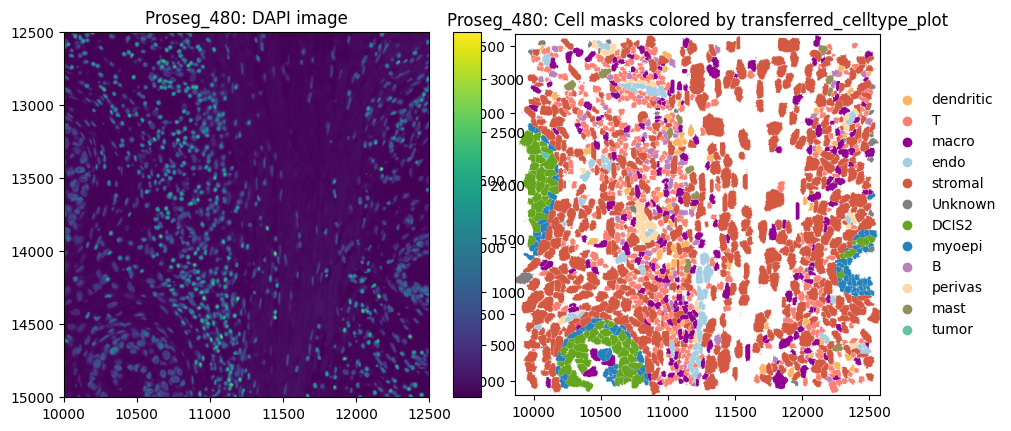

In [14]:
feature_spatial_plot(sdata_proseg_480, "cell_boundaries_z1", "transferred_celltype_plot", col_celltype, "Proseg_480", "morphology_focus")

*Proseg Segmentation (on 5k gene panel)*

INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


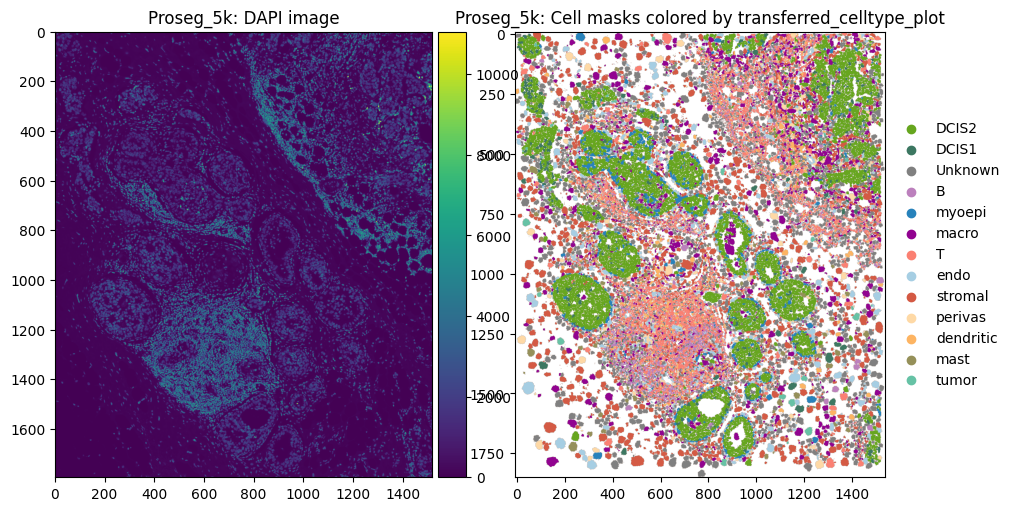

In [15]:
feature_spatial_plot(sdata_proseg_5k, "cell_boundaries_z1", "transferred_celltype_plot", col_celltype, "Proseg_5k", "image")

## Run baseline metrics

In [32]:
for method, st in st_dict.items():
    st.run_baseline()

In [33]:
def boxplot_per_celltype(st_dict, feature, q=1):
    dfs = []
    for method, st in st_dict.items():
        obs = st.sdata["table"].obs[st.sdata["table"].obs["transferred_cell_type"].notna()]
        tmp = obs[["transferred_cell_type", feature]].copy()
        tmp["method"] = method
        dfs.append(tmp)

    df = pd.concat(dfs, ignore_index=True)
    df = df[(df[feature] <= df[feature].quantile(q))]

    fig, ax = plt.subplots(figsize=(15, 5))

    sns.boxplot(
        data=df,
        x="transferred_cell_type",
        y=feature,
        hue="method",
        showcaps=True,
        showfliers=False,
        palette="Set2",
        ax=ax,
    )

    fig.tight_layout()
    plt.show()

We can clearly observe differences in sparsity between the 480-gene and 5k-gene panel data - based on mean transcript count per gene per cell.

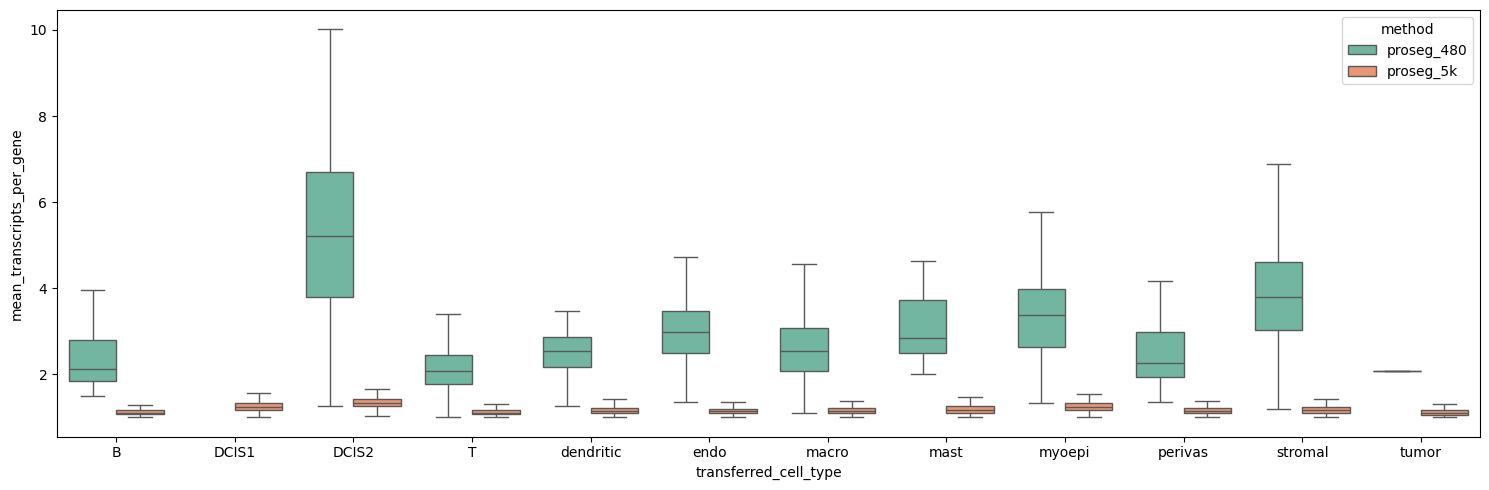

In [34]:
boxplot_per_celltype(st_dict, "mean_transcripts_per_gene")

## Principal component analysis

For each dataset (proseg_480, proseg_5k), we preprocess the labeled cells, run PCA on the highly variable genes, and then fit a separate linear model for each principal component using the transferred cell type labels as predictors. This allows us to quantify how much of the variation in each PC is explained by cell type (via R2) and to identify which cell types drive each PC (via the per-cell-type coefficient estimates).

In [19]:
results_by_method = {}

for method, st in st_dict.items():
    adata = st.sdata.tables["table"].copy()

    # keep only labeled cells
    adata = adata[adata.obs["transferred_cell_type"].notna()].copy()

    # preprocessing
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat")
    adata = adata[:, adata.var["highly_variable"]].copy()

    #from Robert's slides: the argument in favor of rescaling is that it will tend to put the variables on a more equal footing
    #but rescaling may be problematic in some settings (eg when some features are more important) and careful consideration of whether or not to rescale is essential
    # I tried both and no scaling improves the result
    #sc.pp.scale(adata, max_value=10)

    # PCA
    sc.tl.pca(adata, n_comps=50, svd_solver="arpack")

    pcs = pd.DataFrame(
        adata.obsm["X_pca"],
        index=adata.obs_names,
        columns=[f"PC{i+1}" for i in range(adata.obsm["X_pca"].shape[1])]
    )

    # one-hot encode labels
    labels = adata.obs["transferred_cell_type"].astype("category")
    X = pd.get_dummies(labels, drop_first=False).astype(float)

    model_summaries = []
    coef_tables = []

    for pc in pcs.columns:
        model = sm.OLS(pcs[pc], X).fit()

        model_summaries.append({
            "PC": pc,
            "R2": model.rsquared,
            "adj_R2": model.rsquared_adj,
            "pval_model": model.f_pvalue
        })

        conf_int = model.conf_int()
        coef_tables.append(pd.DataFrame({
            "PC": pc,
            "cell_type": model.params.index,
            "estimate": model.params.values,
            "std_error": model.bse.values,
            "t_value": model.tvalues.values,
            "p_value": model.pvalues.values,
            "ci_low": conf_int[0].values,
            "ci_high": conf_int[1].values
        }))

    pc_r2_df = pd.DataFrame(model_summaries)
    pc_coef_df = pd.concat(coef_tables, ignore_index=True)

    # add PC number and variance explained
    pc_r2_df["PC_num"] = pc_r2_df["PC"].str.replace("PC", "", regex=False).astype(int)
    pc_r2_df["variance_explained"] = adata.uns["pca"]["variance_ratio"][:len(pc_r2_df)]

    # store results for this method
    results_by_method[method] = {
        "pc_r2_df": pc_r2_df,
        "pc_coef_df": pc_coef_df,
        "adata": adata,
    }

We then compare the two datasets by plotting, for each principal component, both the total variance captured by the PC and the fraction of that PC’s variance explained by cell type. This lets us assess whether a method preserves biologically meaningful structure (high cell-type-associated PCs) or introduces additional variation that is less clearly explained by cell identity. On the 5k panel, which is much sparser than the 480-gene panel, the first principal component explains only about 2.5% of the total variance, highlighting how diffuse the overall variation is in this dataset. In both datasets, however, the first two PCs are still largely driven by cell type, indicating that despite the low absolute variance explained, these leading components capture meaningful biological structure.

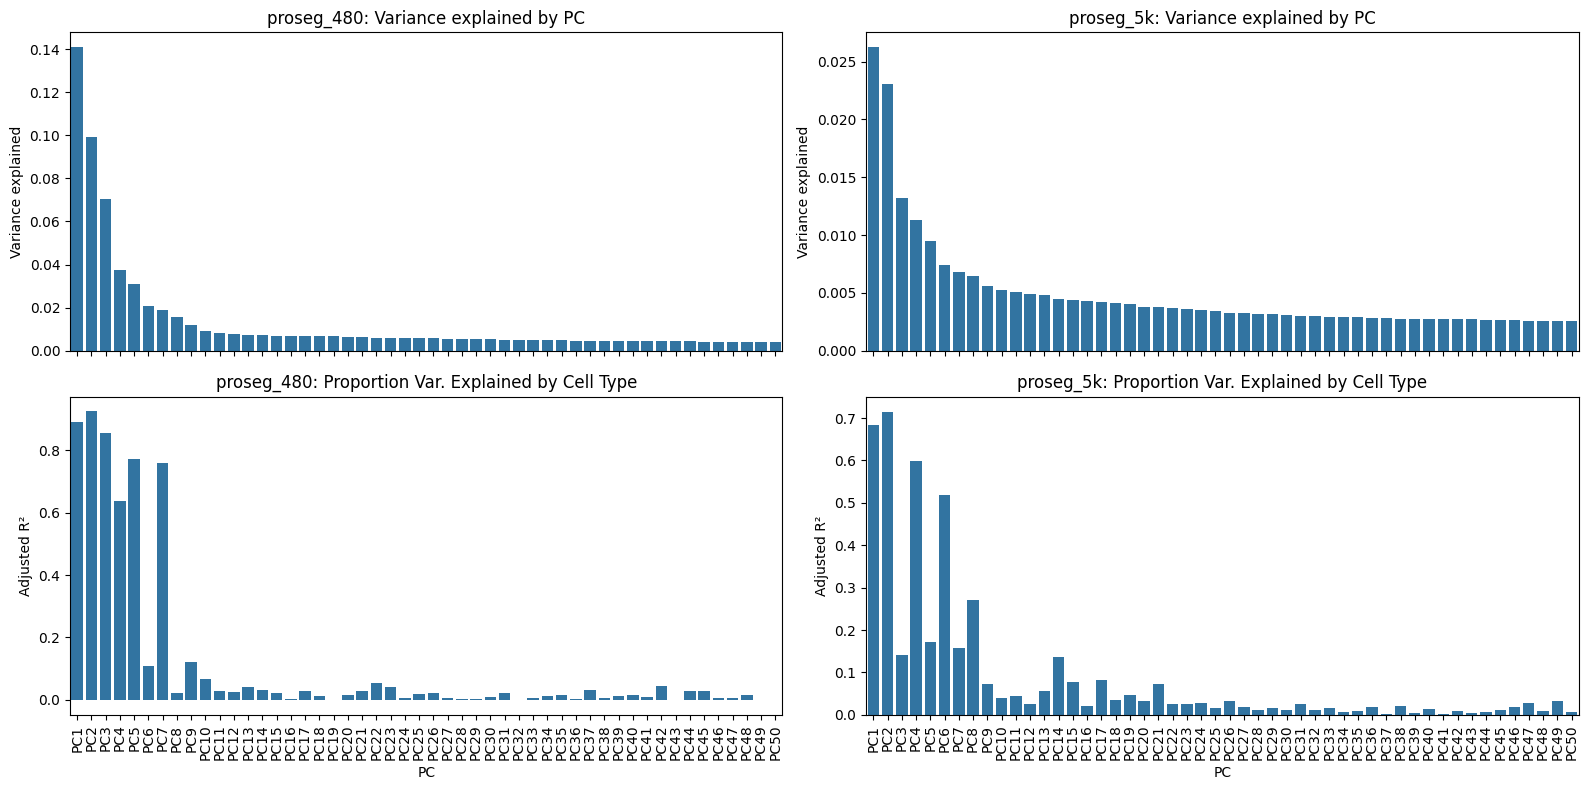

In [24]:
methods = list(results_by_method.keys())

m1, m2 = methods

df1 = results_by_method[m1]["pc_r2_df"].copy()
df2 = results_by_method[m2]["pc_r2_df"].copy()

df1 = df1.sort_values("PC_num")
df2 = df2.sort_values("PC_num")

fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)

sns.barplot(data=df1, x="PC", y="variance_explained", ax=axes[0, 0])
axes[0, 0].set_title(f"{m1}: Variance explained by PC")
axes[0, 0].set_ylabel("Variance explained")
axes[0, 0].tick_params(axis="x", rotation=90)

sns.barplot(data=df2, x="PC", y="variance_explained", ax=axes[0, 1])
axes[0, 1].set_title(f"{m2}: Variance explained by PC")
axes[0, 1].set_ylabel("Variance explained")
axes[0, 1].tick_params(axis="x", rotation=90)

sns.barplot(data=df1, x="PC", y="adj_R2", ax=axes[1, 0])
axes[1, 0].set_title(f"{m1}: Proportion Var. Explained by Cell Type")
axes[1, 0].set_ylabel("Adjusted R²")
axes[1, 0].tick_params(axis="x", rotation=90)

sns.barplot(data=df2, x="PC", y="adj_R2", ax=axes[1, 1])
axes[1, 1].set_title(f"{m2}: Proportion Var. Explained by Cell Type")
axes[1, 1].set_ylabel("Adjusted R²")
axes[1, 1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

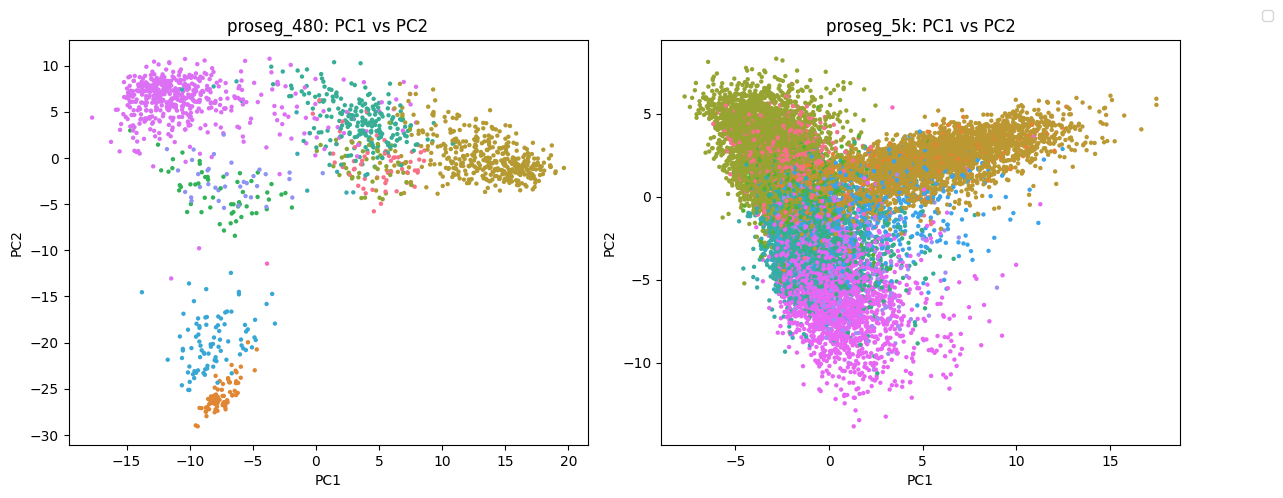

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

for ax, method in zip(axes, methods):
    adata = results_by_method[method]["adata"]

    pcs_plot = pd.DataFrame(
        adata.obsm["X_pca"][:, :2],
        columns=["PC1", "PC2"],
        index=adata.obs_names
    )

    pcs_plot["cell_type"] = adata.obs["transferred_cell_type"].values

    sns.scatterplot(
        data=pcs_plot,
        x="PC1",
        y="PC2",
        hue="cell_type",
        s=10,
        linewidth=0,
        ax=ax,
        legend=False  # avoid duplicate legends
    )

    ax.set_title(f"{method}: PC1 vs PC2")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

# add legend only once (right side)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In the PC1 vs PC2 scatterplot, we observe a clear separation of cell types, consistent with these leading components being strongly driven by biological identity. In contrast, in the PC1 vs PC10 plot, PC10 does not appear to separate cells by cell type, in line with the above plot, showing that this PC is capturing variation that is not primarily explained by cell identity.

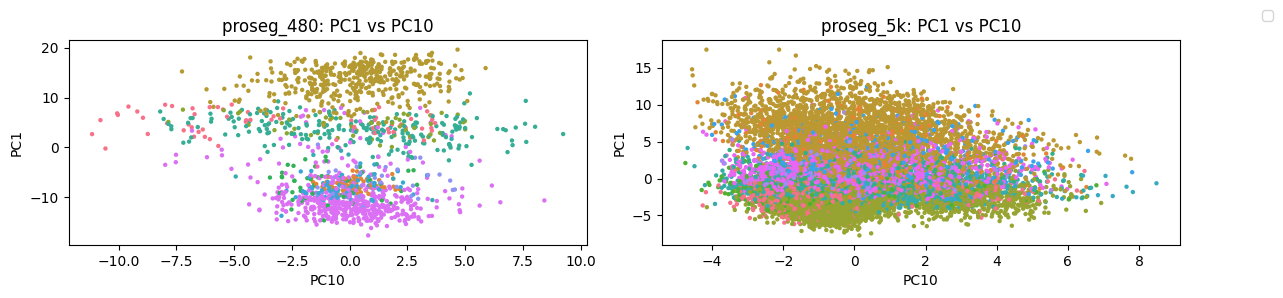

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharex=False, sharey=False)

for ax, method in zip(axes, methods):
    adata = results_by_method[method]["adata"]

    pcs_plot = pd.DataFrame(
        adata.obsm["X_pca"][:, [0, 9]],
        columns=["PC1", "PC10"],
        index=adata.obs_names
    )

    pcs_plot["cell_type"] = adata.obs["transferred_cell_type"].values

    sns.scatterplot(
        data=pcs_plot,
        x="PC10",
        y="PC1",
        hue="cell_type",
        s=10,
        linewidth=0,
        ax=ax,
        legend=False  # avoid duplicate legends
    )

    ax.set_title(f"{method}: PC1 vs PC10")
    ax.set_xlabel("PC10")
    ax.set_ylabel("PC1")

# add legend only once (right side)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

We can also see this difference in the boxplots below, where we plot the distribution of PC values across transferred cell types: PC1 shows clear shifts between cell types, whereas PC10 displays much more overlap, showing that it is not primarily driven by cell identity.

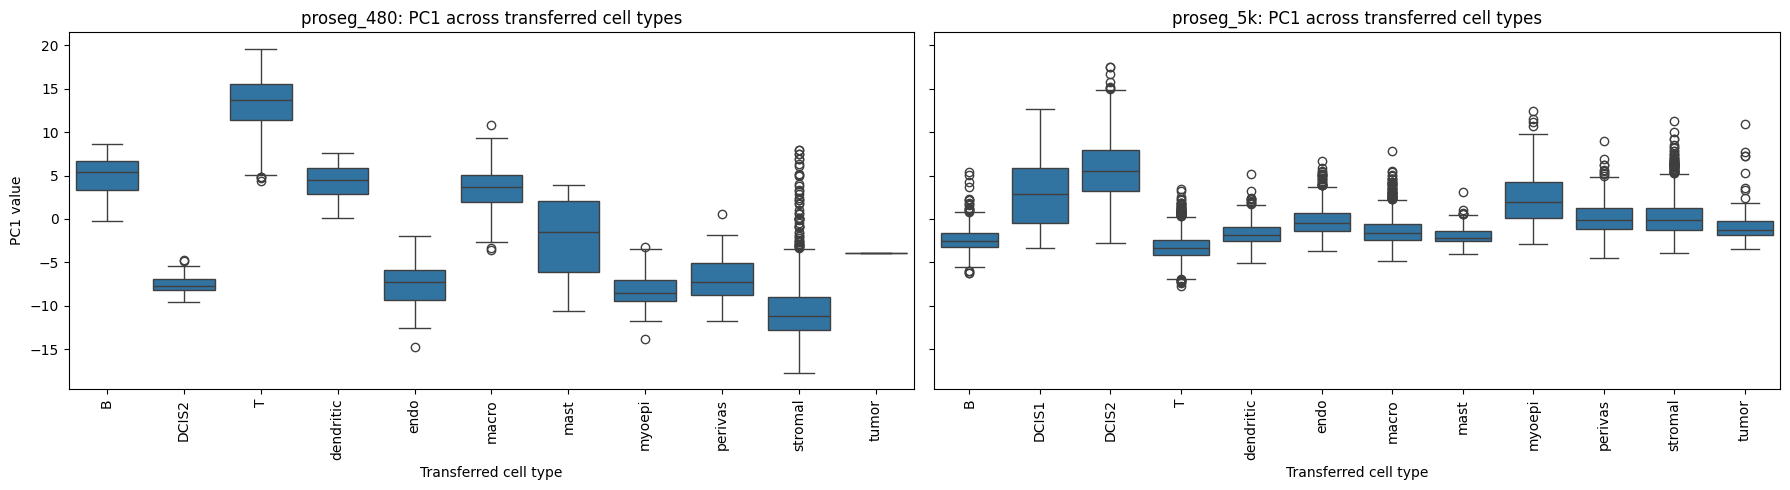

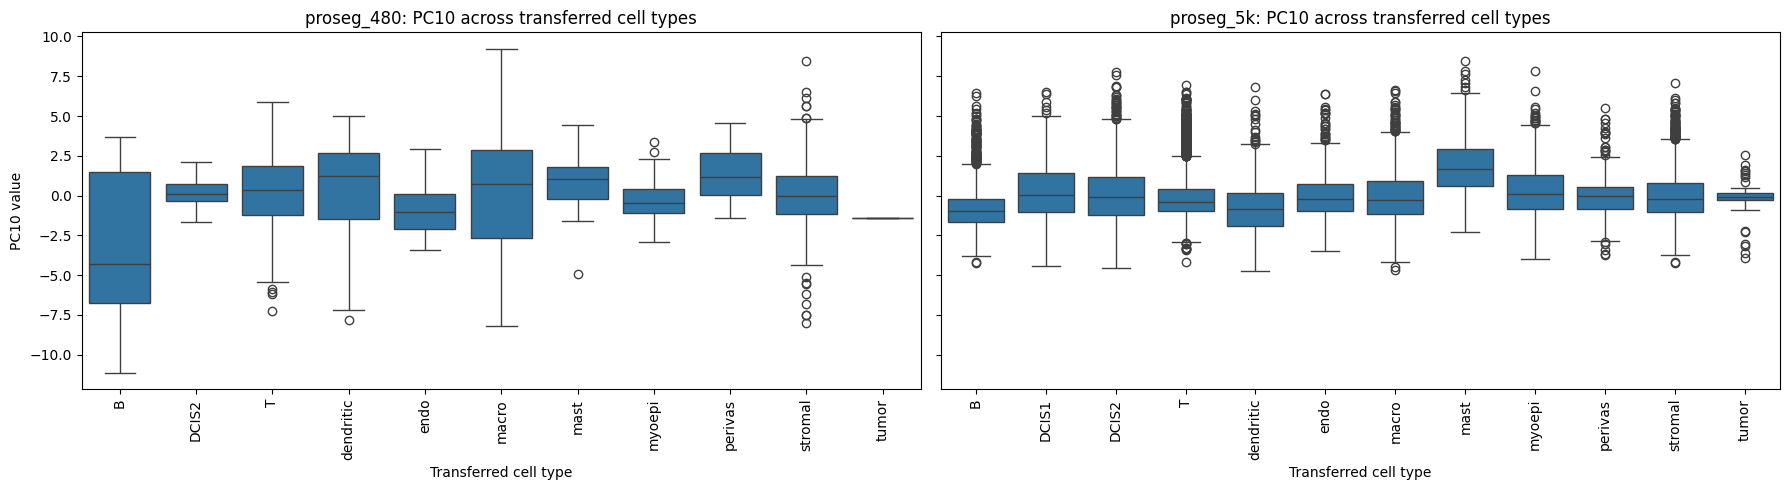

In [30]:
for method in methods:
    adata = results_by_method[method]["adata"]
    for i in range(adata.obsm["X_pca"].shape[1]):
        adata.obs[f"PC{i+1}"] = adata.obsm["X_pca"][:, i]

for pc in ["PC1", "PC10"]:
    fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

    for ax, method in zip(axes, methods):
        adata = results_by_method[method]["adata"]

        sns.boxplot(
            data=adata.obs,
            x="transferred_cell_type",
            y=pc,
            ax=ax
        )

        ax.set_title(f"{method}: {pc} across transferred cell types")
        ax.set_xlabel("Transferred cell type")
        ax.set_ylabel(f"{pc} value")
        ax.tick_params(axis="x", rotation=90)

    plt.tight_layout()
    plt.show()

In the elbow and cumulative variance explained plots below, we see that in the 480-gene panel, the first 50 PCs capture about 70% of the total variance, whereas in the 5k panel, the same number of PCs capture only about 20–30%. This is because the larger, sparser gene panel distributes variance across many more dimensions, leading to more diffuse variation where no small set of PCs dominates.

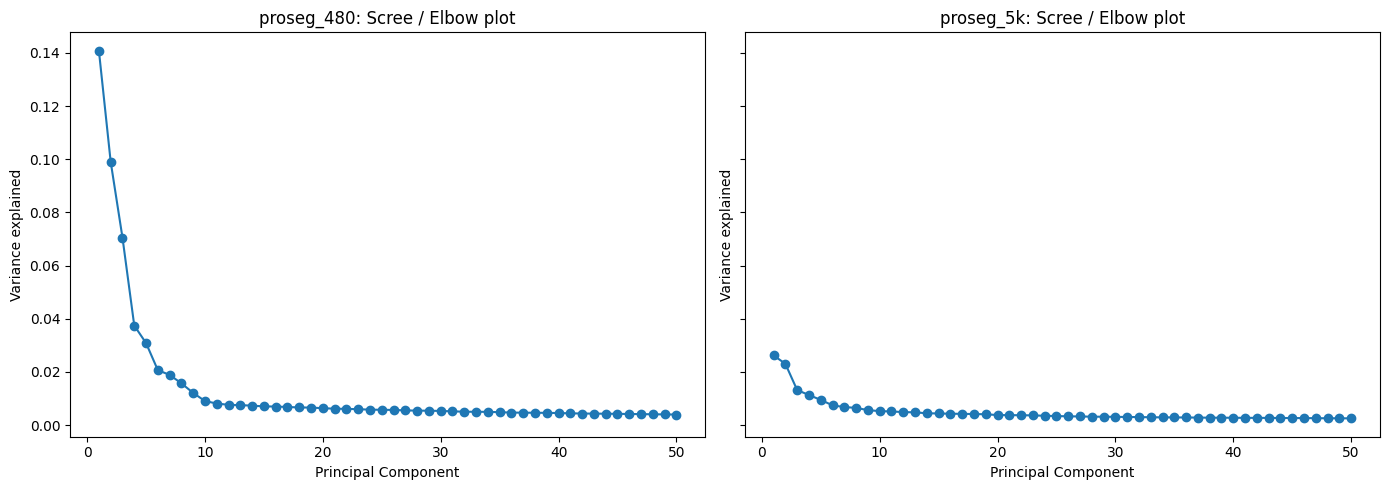

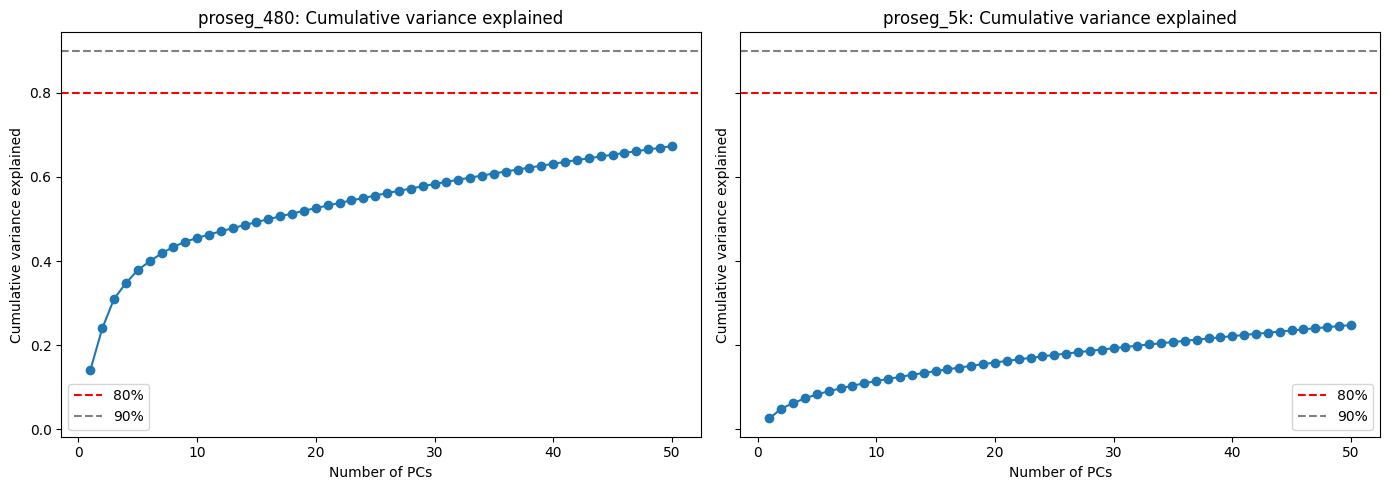

In [ ]:
methods = list(results_by_method.keys())
assert len(methods) == 2, "This code assumes exactly 2 methods."

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, method in zip(axes, methods):
    adata = results_by_method[method]["adata"]
    var_ratio = adata.uns["pca"]["variance_ratio"]

    ax.plot(range(1, len(var_ratio) + 1), var_ratio, marker="o")
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Variance explained")
    ax.set_title(f"{method}: Scree / Elbow plot")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, method in zip(axes, methods):
    adata = results_by_method[method]["adata"]
    var_ratio = adata.uns["pca"]["variance_ratio"]
    cum_var = np.cumsum(var_ratio)

    ax.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
    ax.axhline(0.8, linestyle="--", color="red", label="80%")
    ax.axhline(0.9, linestyle="--", color="gray", label="90%")
    ax.set_xlabel("Number of PCs")
    ax.set_ylabel("Cumulative variance explained")
    ax.set_title(f"{method}: Cumulative variance explained")
    ax.legend()

plt.tight_layout()
plt.show()

## Next

In a next step, we can investigate what drives the variation in the remaining PCs that are not well explained by cell type, and test whether these components are associated with contamination-related metrics from SegTraQ.